In [2]:
import sys
sys.path.append('../src')
import numpy as np
import os
from data_utils import *
from dl_utils import *
from model_analysis.Weights_initialization import *
from sklearn.model_selection import train_test_split

In [3]:
DATA_PATH = r"data/df_sp_500_log_ret.csv"
df = pd.read_csv(DATA_PATH, index_col='Date')

LAGS = 10
X, y = build_dataset_abs_returns(df, LAGS)
X, y, scaler_x, scaler_y = scale_data(X,y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=80718)


In [ ]:
neural_network = NeuralNetwork(                                                                                                                                                                           
    layers=[                                                                                                                                                                                              
        Dense(neurons=32, activation=ReLU(), weight_init='standard'),                                                                                                                                                                                                                                                                                      
        Dense(neurons=1,  activation=Linear())  
    ],                                                                                                                                                                                                    
    loss=MeanSquaredError()                                                                                                                                                                             
) 
optimizer = SGD(lr = 0.001)

# Weight Initialization

Weight initialization determines the starting distribution of the network's parameters before any training. It has a massive impact on:
- Whether gradients vanish (become too small) or explode (become too large) during backpropagation
- How fast the network converges
- Whether neurons are active or dead at the start

Each cell below shows for a given init strategy:
- **Row 1 — Weight distributions**: how parameters are spread before vs after training
- **Row 2 — Pre-activation**: the signal entering each activation function
- **Row 3 — Post-activation**: the signal leaving each activation function

A good initialization keeps pre-activation values centered around 0 with reasonable variance across all layers. If the post-activation distribution collapses (all values the same) or explodes, the network cannot learn.

---
## Standard Normal — `N(0, 1)`

**Formula**: `W ~ N(0, 1)` — no scaling at all

**How it works**: weights are drawn from a standard normal distribution with variance 1. No account is taken of the number of inputs or outputs.

**Pros:**
- Simple, no hyperparameters
- Fine for very shallow networks (1–2 layers)

**Cons:**
- In deep networks, the variance of activations grows with depth — signals either explode or vanish
- With Sigmoid/Tanh: large initial weights saturate the activation immediately, gradient becomes ~0 from the first forward pass
- With ReLU: can cause exploding activations

**When to use**: never in deep networks — only as a baseline to understand why better initializations exist

Validation loss after 10 epochs is 0.754610
Validation loss after 20 epochs is 0.742431
Validation loss after 30 epochs is 0.740518
No improvement after epoch 40 (1/5), best loss: 0.740518
No improvement after epoch 50 (2/5), best loss: 0.740518
No improvement after epoch 60 (3/5), best loss: 0.740518
Validation loss after 70 epochs is 0.739010
No improvement after epoch 80 (1/5), best loss: 0.739010
No improvement after epoch 90 (2/5), best loss: 0.739010
No improvement after epoch 100 (3/5), best loss: 0.739010
No improvement after epoch 110 (4/5), best loss: 0.739010
No improvement after epoch 120 (5/5), best loss: 0.739010
Early stopping triggered. Restoring best model.


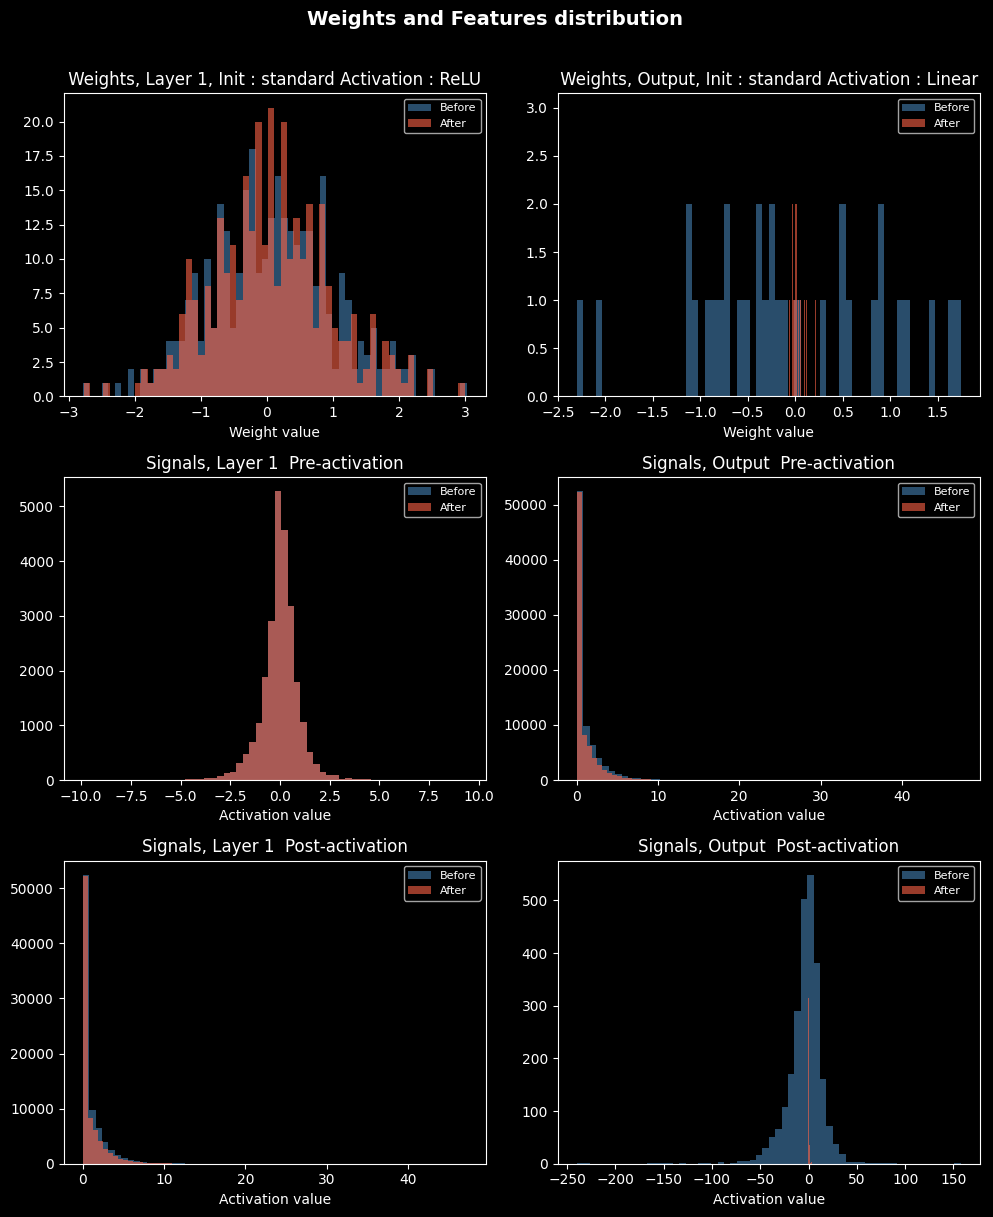

In [4]:
plot_init_analysis(neural_network,
                    X_train, y_train, X_test, y_test,
                    optimizer )

---
## Glorot Normal (Xavier Normal) — `N(0, sqrt(2 / (n_in + n_out)))`

**Formula**: `W ~ N(0, sqrt(2 / (n_in + n_out)))` 

**How it works**: proposed by Glorot & Bengio (2010). Scales variance so that the signal variance is preserved in both the forward and backward passes simultaneously, by balancing `n_in` and `n_out`.

**Pros:**
- Keeps activation variance stable across layers with Sigmoid and Tanh
- Prevents both vanishing and exploding gradients for symmetric activations


**Cons:**
- Derived assuming linear activations — suboptimal for ReLU (which kills half the neurons)
- Normal variant can occasionally produce large outliers; uniform variant is more controlled

**Best with**: `Sigmoid`, `Tanh`, `Linear`

Validation loss after 10 epochs is 0.775998
Validation loss after 20 epochs is 0.731035
Validation loss after 30 epochs is 0.727644
No improvement after epoch 40 (1/5), best loss: 0.727644
No improvement after epoch 50 (2/5), best loss: 0.727644
No improvement after epoch 60 (3/5), best loss: 0.727644
No improvement after epoch 70 (4/5), best loss: 0.727644
No improvement after epoch 80 (5/5), best loss: 0.727644
Early stopping triggered. Restoring best model.


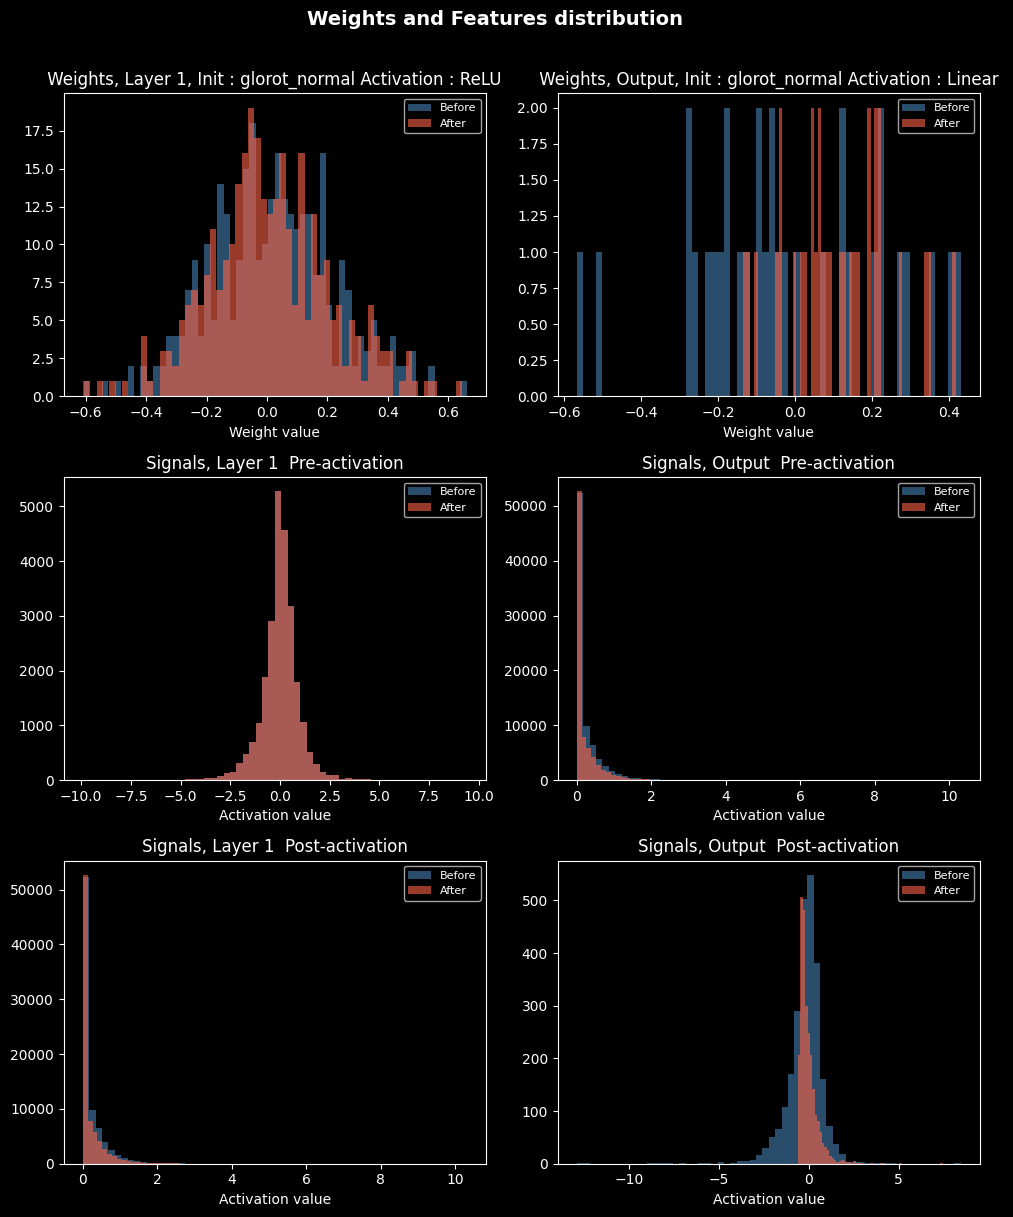

In [5]:
weight_init = 'glorot_normal'
neural_network = NeuralNetwork(                                                                                                                                                                           
    layers=[                                                                                                                                                                                              
        Dense(neurons=32, activation=ReLU(), weight_init= weight_init),                                                                                                                                                                                                                                                                                      
        Dense(neurons=1,  activation=Linear(), weight_init= weight_init)  
    ],                                                                                                                                                                                                    
    loss=MeanSquaredError()                                                                                                                                                                             
) 
optimizer = SGD(lr = 0.001) 
plot_init_analysis(neural_network,
                    X_train, y_train, X_test, y_test,
                    optimizer )

---
## Glorot Uniform (Xavier Uniform) — `U(-sqrt(6 / (n_in + n_out)), sqrt(6 / (n_in + n_out)))`

**Formula**: `W ~ U(-sqrt(6 / (n_in + n_out)), sqrt(6 / (n_in + n_out)))`

**How it works**: same theory as Glorot Normal but using a uniform distribution. The `sqrt(3)` factor makes the variance of a uniform distribution match the target variance (since `Var(U(-a,a)) = a²/3`).

**Pros:**
- Same theoretical guarantees as Glorot Normal
- Bounded — no risk of extreme outlier values at initialization
- Slightly more stable than the normal variant in practice

**Cons:**
- Same limitation as Glorot Normal for ReLU
- Uniform distribution may not match the Gaussian assumption underlying backprop analysis

**Best with**: `Sigmoid`, `Tanh`, `Linear`

Validation loss after 10 epochs is 0.900960
Validation loss after 20 epochs is 0.864400
Validation loss after 30 epochs is 0.849706
Validation loss after 40 epochs is 0.838673
Validation loss after 50 epochs is 0.828445
Validation loss after 60 epochs is 0.818821
Validation loss after 70 epochs is 0.809137
Validation loss after 80 epochs is 0.800310
Validation loss after 90 epochs is 0.793011
Validation loss after 100 epochs is 0.786531
Validation loss after 110 epochs is 0.780871
Validation loss after 120 epochs is 0.777492
Validation loss after 130 epochs is 0.774255
Validation loss after 140 epochs is 0.771520
Validation loss after 150 epochs is 0.769316
Validation loss after 160 epochs is 0.768837
Validation loss after 170 epochs is 0.768470
No improvement after epoch 180 (1/5), best loss: 0.768470
No improvement after epoch 190 (2/5), best loss: 0.768470
Validation loss after 200 epochs is 0.768346
No improvement after epoch 210 (1/5), best loss: 0.768346
No improvement after epoc

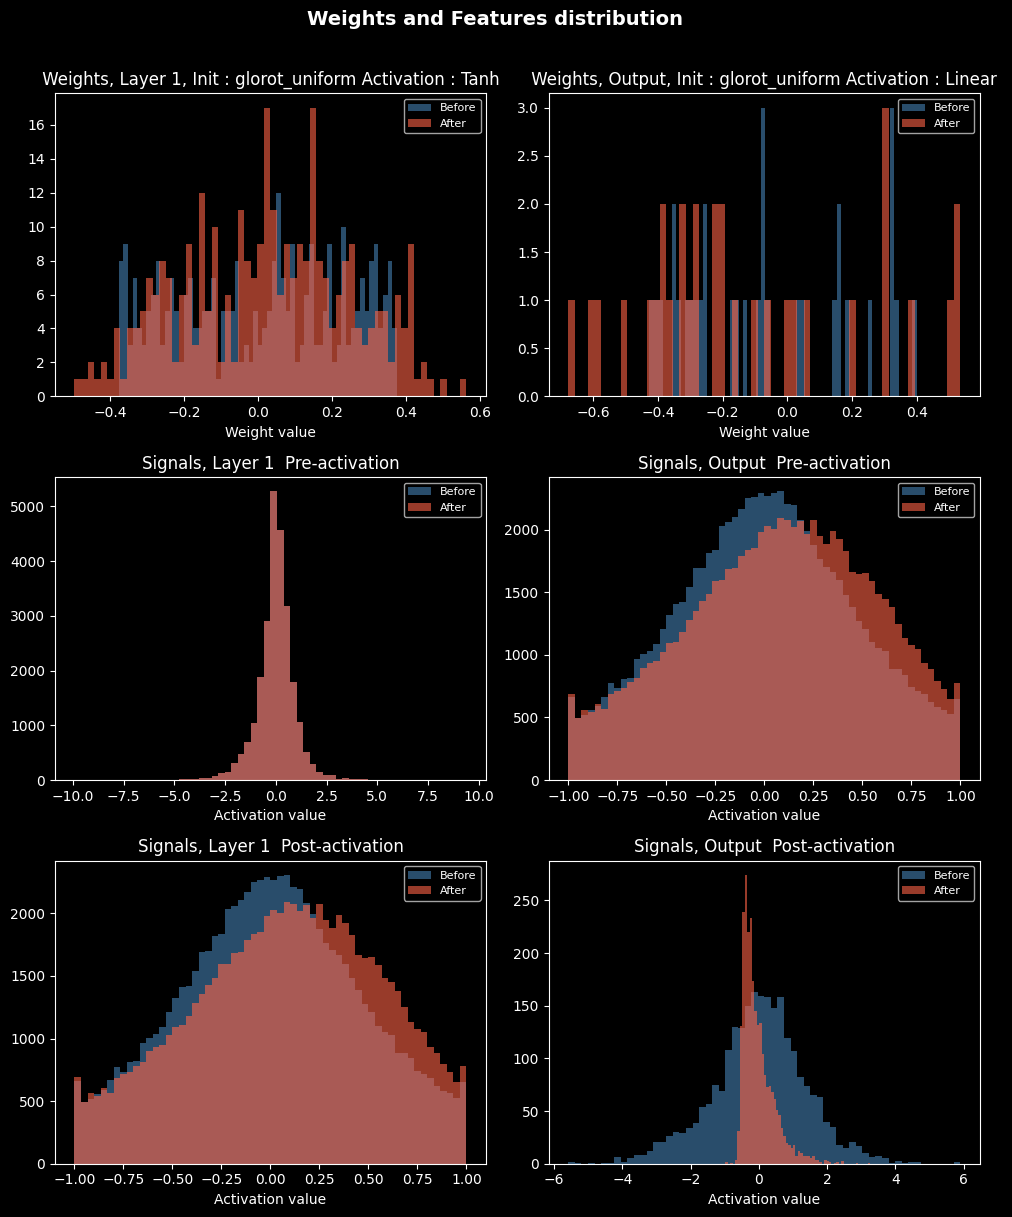

In [6]:
weight_init = 'glorot_uniform'
neural_network = NeuralNetwork(                                                                                                                                                                           
    layers=[                                                                                                                                                                                              
        Dense(neurons=32, activation=Tanh(), weight_init= weight_init),                                                                                                                                                                                                                                                                                      
        Dense(neurons=1,  activation=Linear(), weight_init= weight_init)  
    ],                                                                                                                                                                                                    
    loss=MeanSquaredError()                                                                                                                                                                             
) 
optimizer = SGD(lr = 0.001) 
plot_init_analysis(neural_network,
                    X_train, y_train, X_test, y_test,
                    optimizer )

---
## He Normal (Kaiming Normal) — `N(0, sqrt(2 / n_in))`

**Formula**: `W ~ N(0, sqrt(2 / n_in))`

**How it works**: proposed by He et al. (2015). Fixes Glorot for ReLU by using only `n_in` (not `n_out`), and scaling by 2 to compensate for ReLU zeroing out half the neurons. The factor of 2 maintains variance through a ReLU layer.

**Pros:**
- Specifically designed for ReLU — keeps signal variance stable across deep ReLU networks
- Strong empirical results on deep architectures (ResNet, VGG)
- Default in PyTorch for Conv and Linear layers with ReLU

**Cons:**
- Suboptimal for Sigmoid/Tanh (too large variance causes saturation)
- Normal variant can produce outliers; uniform variant is more bounded

**Best with**: `ReLU`, `Leaky ReLU`, `ELU`

Validation loss after 10 epochs is 0.736370
Validation loss after 20 epochs is 0.733066
No improvement after epoch 30 (1/5), best loss: 0.733066
No improvement after epoch 40 (2/5), best loss: 0.733066
No improvement after epoch 50 (3/5), best loss: 0.733066
No improvement after epoch 60 (4/5), best loss: 0.733066
No improvement after epoch 70 (5/5), best loss: 0.733066
Early stopping triggered. Restoring best model.


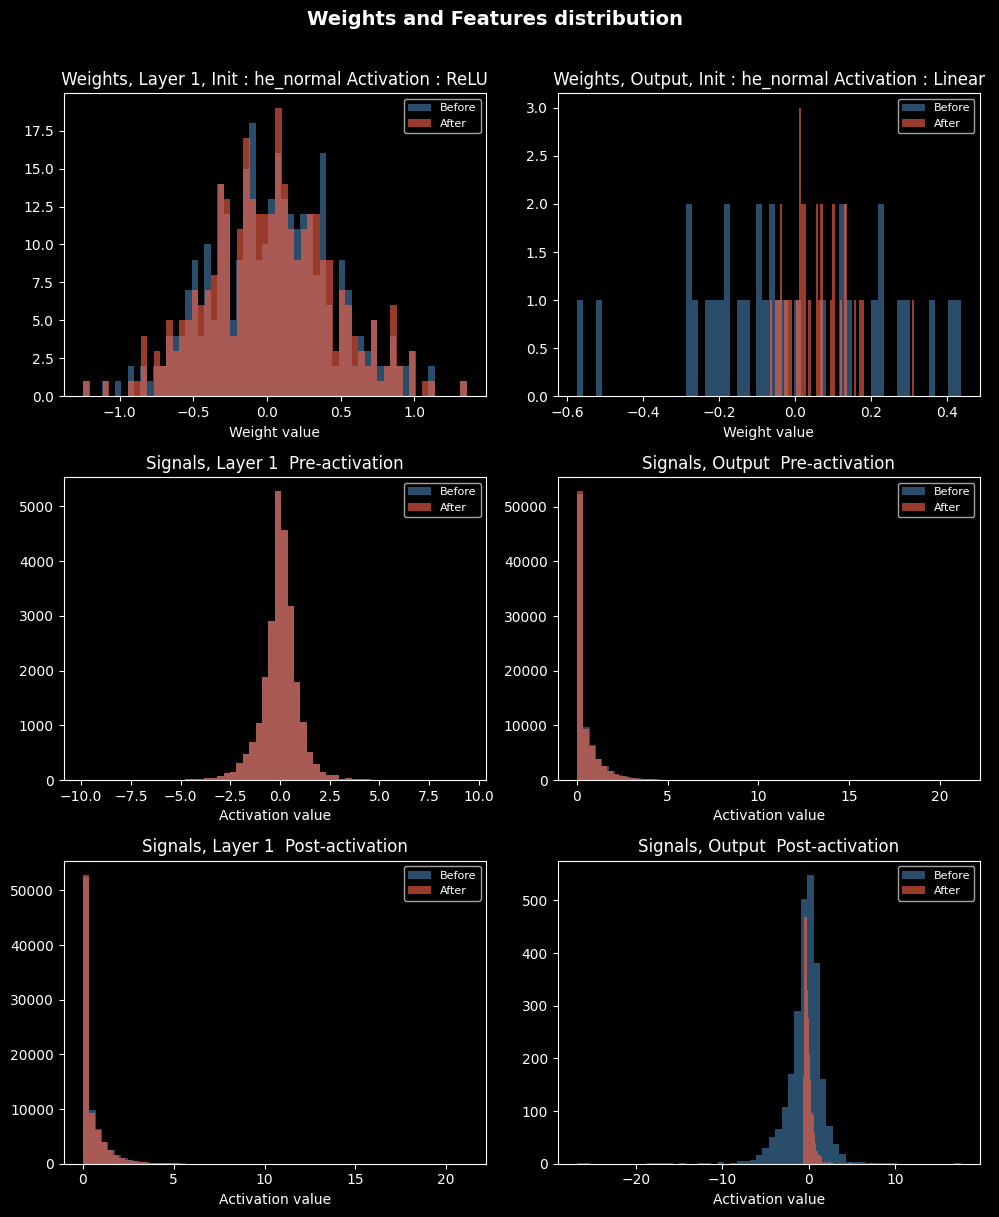

In [7]:
weight_init = 'he_normal'
neural_network = NeuralNetwork(                                                                                                                                                                           
    layers=[                                                                                                                                                                                              
        Dense(neurons=32, activation=ReLU(), weight_init= weight_init),                                                                                                                                                                                                                                                                                      
        Dense(neurons=1,  activation=Linear(), weight_init= weight_init)  
    ],                                                                                                                                                                                                    
    loss=MeanSquaredError()                                                                                                                                                                             
) 
optimizer = SGD(lr = 0.001) 
plot_init_analysis(neural_network,
                    X_train, y_train, X_test, y_test,
                    optimizer )

---
## He Uniform (Kaiming Uniform) — `U(-sqrt(6 / n_in), sqrt(6 / n_in))`

**Formula**: `W ~ U(-sqrt(6 / n_in), sqrt(6 / n_in))`

**How it works**: uniform version of He initialization. Same scaling factor but bounded, so no extreme values at init.

**Pros:**
- Same theoretical guarantees as He Normal
- Bounded initialization — more predictable range of starting weights
- Actually the default in PyTorch `nn.Linear` (with a small modification for Leaky ReLU)

**Cons:**
- Same limitations as He Normal for non-ReLU activations

**Best with**: `ReLU`, `Leaky ReLU`, `ELU`, `Swish`

Validation loss after 10 epochs is 0.732053
Validation loss after 20 epochs is 0.722592
No improvement after epoch 30 (1/5), best loss: 0.722592
No improvement after epoch 40 (2/5), best loss: 0.722592
No improvement after epoch 50 (3/5), best loss: 0.722592
No improvement after epoch 60 (4/5), best loss: 0.722592
No improvement after epoch 70 (5/5), best loss: 0.722592
Early stopping triggered. Restoring best model.


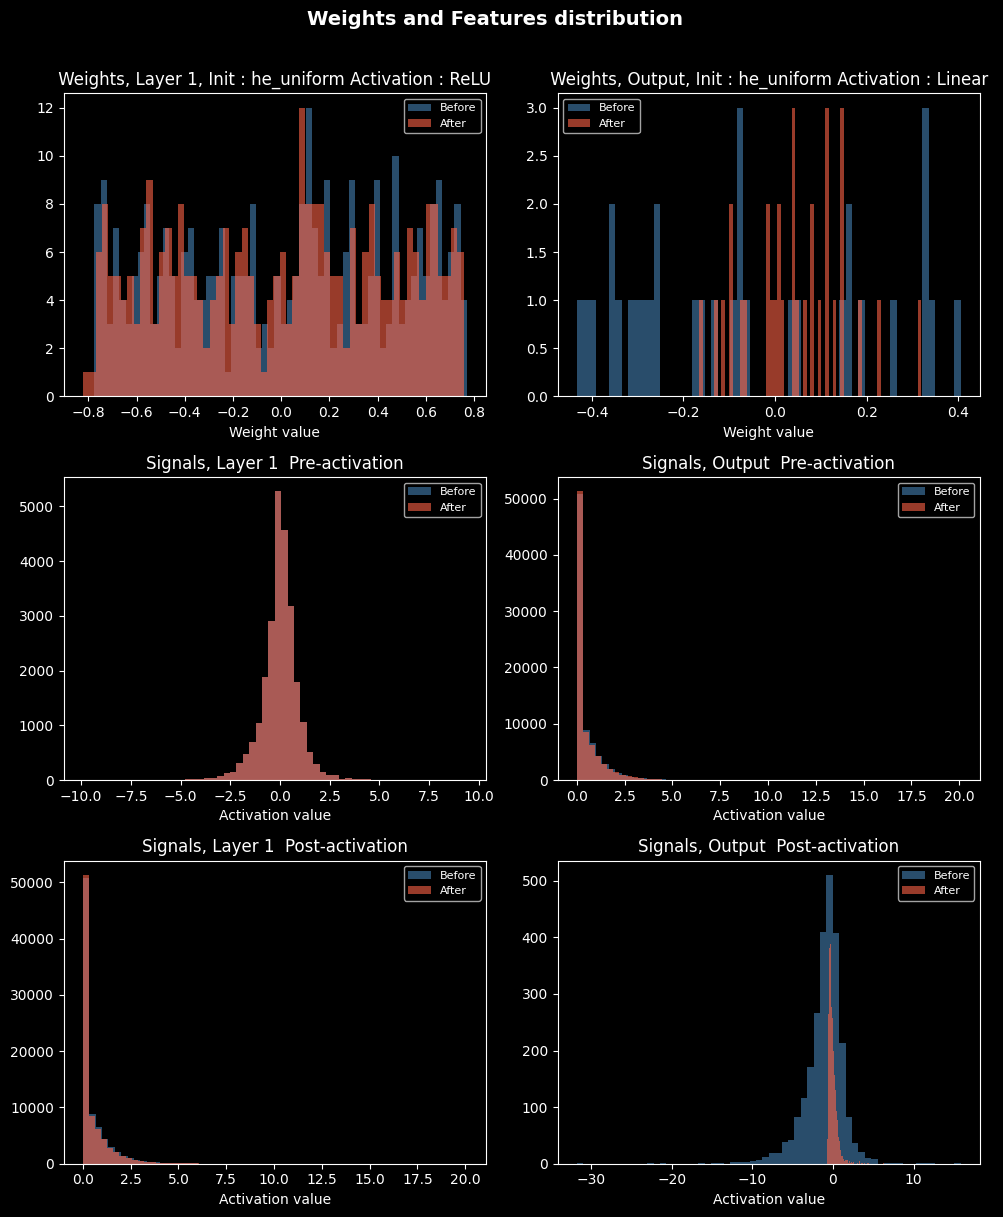

In [8]:
weight_init = 'he_uniform'
neural_network = NeuralNetwork(                                                                                                                                                                           
    layers=[                                                                                                                                                                                              
        Dense(neurons=32, activation=ReLU(), weight_init= weight_init),                                                                                                                                                                                                                                                                                      
        Dense(neurons=1,  activation=Linear(), weight_init= weight_init)  
    ],                                                                                                                                                                                                    
    loss=MeanSquaredError()                                                                                                                                                                             
) 
optimizer = SGD(lr = 0.001) 
plot_init_analysis(neural_network,
                    X_train, y_train, X_test, y_test,
                    optimizer )

---
## LeCun Normal — `N(0, sqrt(1 / n_in))`

**Formula**: `W ~ N(0, sqrt(1 / n_in))`

**How it works**: proposed by LeCun et al. (1998), one of the earliest principled initializations. Scales by `1/n_in` to keep variance of the pre-activation stable in the forward pass only (unlike Glorot which also considers the backward pass). Designed for SELU, which is self-normalizing and does not kill activations.

**Pros:**
- Required for SELU to achieve its self-normalizing property
- Works well for shallow-to-medium networks
- Simpler formula than Glorot (only depends on `n_in`)

**Cons:**
- Does not account for the backward pass — can cause gradient issues in very deep networks
- Slightly smaller variance than He — can underperform with ReLU

**Best with**: SELU (à implémenter dans opération), also reasonable for `Sigmoid`, `Tanh`

Validation loss after 10 epochs is 0.885836
Validation loss after 20 epochs is 0.878231
Validation loss after 30 epochs is 0.875195
Validation loss after 40 epochs is 0.872243
Validation loss after 50 epochs is 0.868471
Validation loss after 60 epochs is 0.862664
Validation loss after 70 epochs is 0.856682
Validation loss after 80 epochs is 0.850068
Validation loss after 90 epochs is 0.842605
Validation loss after 100 epochs is 0.836728
Validation loss after 110 epochs is 0.830591
Validation loss after 120 epochs is 0.826034
Validation loss after 130 epochs is 0.821566
Validation loss after 140 epochs is 0.818442
Validation loss after 150 epochs is 0.815914
Validation loss after 160 epochs is 0.813516
Validation loss after 170 epochs is 0.811629
Validation loss after 180 epochs is 0.811240
Validation loss after 190 epochs is 0.811020
Validation loss after 200 epochs is 0.809434
Validation loss after 210 epochs is 0.809155
Validation loss after 220 epochs is 0.807992
Validation loss aft

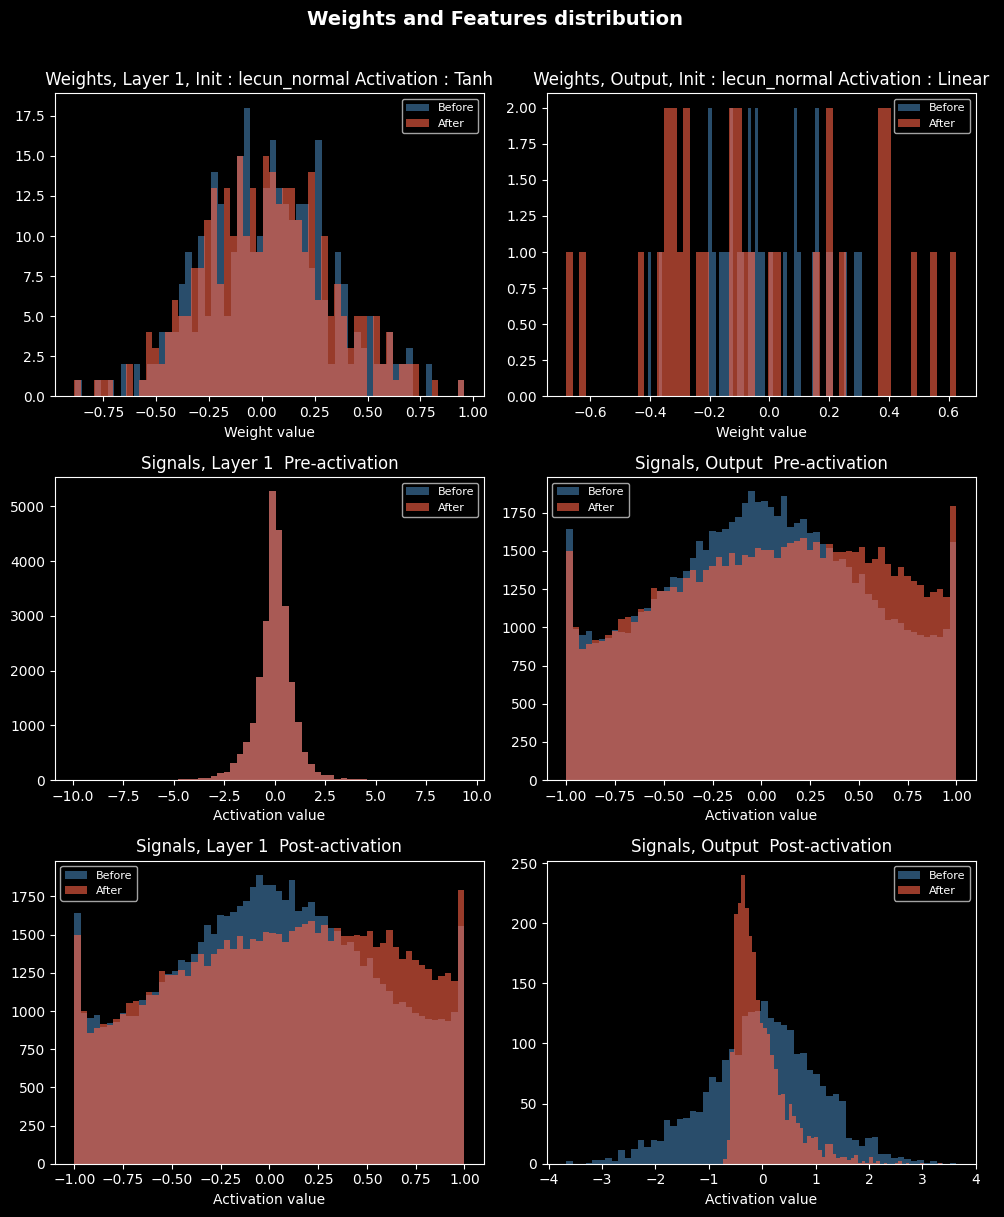

In [9]:
weight_init = 'lecun_normal'
neural_network = NeuralNetwork(                                                                                                                                                                           
    layers=[                                                                                                                                                                                              
        Dense(neurons=32, activation=Tanh(), weight_init= weight_init),                                                                                                                                                                                                                                                                                      
        Dense(neurons=1,  activation=Linear(), weight_init= weight_init)  
    ],                                                                                                                                                                                                    
    loss=MeanSquaredError()                                                                                                                                                                             
) 
optimizer = SGD(lr = 0.001) 
plot_init_analysis(neural_network,
                    X_train, y_train, X_test, y_test,
                    optimizer )

---
## Summary — Which init for which activation?

| Initialization | Formula | Best activation | Avoid with |
|----------------|---------|-----------------|------------|
| Standard Normal | `N(0,1)` | — | Everything in deep networks |
| Glorot Normal | `N(0, sqrt(2/(n_in+n_out)))` | Sigmoid, Tanh, Linear | ReLU |
| Glorot Uniform | `U(±sqrt(6/(n_in+n_out)))` | Sigmoid, Tanh, Linear | ReLU |
| He Normal | `N(0, sqrt(2/n_in))` | ReLU, Leaky ReLU, ELU | Sigmoid, Tanh |
| He Uniform | `U(±sqrt(6/n_in))` | ReLU, Leaky ReLU, Swish | Sigmoid, Tanh |
| LeCun Normal | `N(0, sqrt(1/n_in))` | SELU, Tanh | Very deep networks |

In [12]:
# --- Final comparison: MAE after 50 epochs for each init + matching activation ---
configs = [
    ('standard',       Sigmoid(),  'Sigmoid'),
    ('glorot_normal',  Sigmoid(),  'Sigmoid'),
    ('glorot_uniform', Tanh(),     'Tanh'),
    ('he_normal',      ReLU(),     'ReLU'),
    ('he_uniform',     ReLU(),     'ReLU'),
    ('lecun_normal',   Tanh(),     'Tanh'),
]

print(f"{'Init':<20} {'Activation':<12} {'MAE':>8}")
print('-' * 42)

for weight_init, activation, act_name in configs:
    
    net = NeuralNetwork(                                                                                                                                                                           
                        layers=[                                                                                                                                                                                              
                            Dense(neurons=32, activation=activation, weight_init= weight_init),                                                                                                                                                                                                                                                                                      
                            Dense(neurons=1,  activation=Linear(), weight_init= weight_init)  
                            ],                                                                                                                                                                                                    
                        loss=MeanSquaredError()                                                                                                                                                                             
                    )                                                                                                                                                                    
    optimizer = SGD(lr = 0.001) 
    trainer = Trainer(net, optimizer)
    trainer.fit(X_train, y_train, X_test, y_test,                                                                                                                                                             
                epochs=300,                                                                                                                                                                                           
                eval_every=10,  
                seed = 201906501,                                                                                                                                                                                     
                patience=5,
                verbose = False)
    preds = net.forward(X_test)
    mae = np.mean(np.abs(preds - y_test))
    print(f"{weight_init:<20} {act_name:<12} {mae:>8.4f}")

Init                 Activation        MAE
------------------------------------------
standard             Sigmoid        0.6146
glorot_normal        Sigmoid        0.6283
glorot_uniform       Tanh           0.5945
he_normal            ReLU           0.5908
he_uniform           ReLU           0.5822
lecun_normal         Tanh           0.6028


In [15]:
import numpy as np                                                                                                                                                                                      
from src.dl_utils import *                                                                                                                                                                                    
   
 

Outputs differ (dropout active): True
Outputs identical (no dropout): True
